In [6]:
from dotenv import load_dotenv

load_dotenv()

True

In [7]:
# LLM 선언 - AzureOpenAI 로 활용해도 됨

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini") 
small_llm = ChatOpenAI(model="gpt-4o-mini")

In [8]:
# checkpointer는 필수
# interrupt를 활용할때 다시 재개해야 할 경우, 멈췄던 시점부터 다시 시작
# 기억을 해야 하기 때문에 히스토리는  필수

In [9]:
from langchain_core.tools import tool


@tool
def add(a: int, b:int) -> int:
    """
        숫자 a 와 b를 더합니다    
    """
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """
        숫자 a 와 b를 곱합니다    
    """
    return a * b


In [10]:
from langchain_community.tools import DuckDuckGoSearchRun


search_tool = DuckDuckGoSearchRun()

In [11]:
# Gmail 도구를 추가
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)
from langchain_google_community import GmailToolkit

# 이 방식을 추천 => 변수를 넘기면서 credential, token json 파일을 관리할 수 있다
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",   # credentials를 기반으로 메일 권한을 가지고 토큰을 생성해서 파일에 저장
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",   #client_sercret_file 오타가 있는 파라미터로...
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)

# 한번 인증을 받으면, 다시 실행해도 넘어간다. 
# gmail_toolkit에서 도구를 받아올 수 있는 상태. 
gmail_tool_list = gmail_toolkit.get_tools()
# toolkit = GmailToolkit()   # 이걸 활용하고자 한다면 -> 파일 이름 명시 불가. credential.json이라고만 해줘야 함 (위 코드 참고)

C:\Users\Yurim Park\AppData\Local\Temp\ipykernel_15264\1902096436.py:9: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(


Please visit this URL to authorize this application: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=761671585438-ai004uutk7bc4je271teir6mb9u61uua.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A52690%2F&scope=https%3A%2F%2Fmail.google.com%2F&state=Zb69uDj4itn1g4rMLeW2kwTZwHsaKw&code_challenge=-RtSsgxmTuEcR39dpvox2itKdqC1mHp2zDsqP6XUpEE&code_challenge_method=S256&access_type=offline


C:\Users\Yurim Park\AppData\Local\Temp\ipykernel_15264\1902096436.py:14: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [12]:
gmail_tool_list
# %pip freeze > requirements.txt

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x00000285249FA270>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x00000285249FA270>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x00000285249FA270>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x00000285249FA270>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x00000285249FA270>)]

In [13]:
%pip install -qU  langchain-community arxiv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
# %pip install langchain --upgrade

In [15]:
# 아카이브 논문 툴
# from langchain.agents import load_tools  # ImportError: cannot import name 'load_tools' from 'langchain.agents'  에러
from langchain_community.agent_toolkits.load_tools import load_tools
from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(temperature=0.0)
loaded_tool_list = load_tools(
    ["arxiv"],
)


#### create_retriever_tool

In [16]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.tools.retriever import create_retriever_tool  


embedding_function = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='real_estate_tax',
    persist_directory='./real_estate_tax_collection'  # 로컬에 남아있음
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})  # 검색할 때, 가장 유사한 3개의 문서를 가져오도록 설정

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax'
)

#### langgraph에서 ToolNode

In [17]:
from langgraph.prebuilt import ToolNode

# tool_list = [add, multiply, search_tool, gmail_tool_list]
tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list  + loaded_tool_list

llm_with_tools = small_llm.bind_tools(tool_list)  # LLM 바인딩 
tool_node = ToolNode(tool_list)   # 랭그래프 바인딩 

In [18]:
# state 선언 : messages의 경우, langgraph가 내장으로 제공하는 state가 있다
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str




# graph_builder = StateGraph(MessagesState)
graph_builder = StateGraph(AgentState)



In [19]:
# 1. 에이전트 노드를 생성 <- LLM을 호출하는, llm_with_tools는 messages를 넣어서 invoke만 하는 용도로...

# HumanMessage -> messages 에 추가
# AiMessage -> messages 에 추가
# ToolMessage -> messages 에 추가
# 추가할 때, append 할 필요는 아니고, add_messages 함수를 활용해서 추가할 수 있다.

from langchain_core.messages import SystemMessage

def agent(state: AgentState):
    messages = state['messages']
    print(f'len(messages) == {len(messages)}')  # 히스토리 관리를 위한 로그

    summary = state['summary']
    if summary != '':
        messages = [SystemMessage(content=f'here is the summary of the earlier conversation: {summary}')] + messages   # 마지막에 대화 이력을 넣어주는 것 (summary는 delete 된 것들의 요약)
         
    response = llm_with_tools.invoke(messages)   # ai_messages와 동일
    
    return {'messages':[response]}

In [20]:
from langgraph.types import interrupt, Command

In [21]:
from typing import Literal

def human_review(state: AgentState)  -> Command[Literal['tools']]:
    messages = state['messages']  # 전체 리스트를 가지고 온다
    last_message = messages[-1]   # 가장 마지막 메시지에 review를 해야 함
    tool_call = last_message.tool_calls[-1]
    human_review = interrupt ({
        'question': '어떻게 진행하면 될까요?',
        'tool_call': tool_call
    })
    review_action = human_review['action']  # 사람이 작성할 내용 (3가지 - 노션 참고 케이스를 action으로 표현해준다)
    review_data = human_review.get('data', None)  # 호출할때 활용할 data -> args로 넘겨준다. 

    # Human Action
    if review_action == 'continue':   # LLM이 잘 했을 때
        return Command(goto='tools')
    
    

In [22]:
# 삭제 전, 메시지 요약

def summarize_message(state: AgentState):
    messages = state['messages']
    summary  = state['summary']
    summary_prompt = 'summarize this chat history below: \n\nchat_history:{messages}'
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversation
        chat_history: {messages}
        summary: {summary}
        '''
    summary = small_llm.invoke(summary_prompt)
    response = llm_with_tools.invoke(messages) 
    
    # return {'messages' : [response]}
    return {'messages' : response.content}

In [23]:
from langchain_core.messages import RemoveMessage


def delete_messages(state:AgentState):
    messages = state['messages']
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages' : delete_messages}

In [24]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node) 
# should_continue -> 분간하는 노드는 추가 안함

graph_builder.add_node('human_review', human_review)
graph_builder.add_node('delete_messages', delete_messages)  # 노드와 이름이 동일하면, 이렇게 작성해도 됨
graph_builder.add_node('summarize_message', summarize_message) 

In [25]:
def should_continue(state:MessagesState):
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'human_review'
    return 'delete_messages'

In [26]:
# 엣지 추가
from langgraph.graph import START, END
from langgraph.prebuilt import tools_condition  # tools condition -> 실행하면 should continue 노드가 불필요해진다

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue, 
    ['human_review', 'summarize_message']
)

graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_message', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

### Checkpoints

In [27]:
from langgraph.checkpoint.memory import MemorySaver

# MemorySaver -> 히스토리 관리
checkpointer = MemorySaver()

graph = graph_builder.compile(
    checkpointer = checkpointer
)

# 이 부분만 추가해주고 실행하면 -> "ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id" 에러가 발생함
# 체크포인트 관리 시, thread를 관리해야 함. ->  thread_id를 지정해줘야 함 

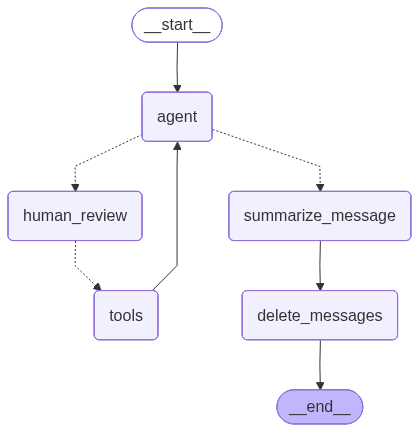

In [28]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))  


In [35]:
# 호출
from langchain_core.messages import HumanMessage

config = {
    'configurable' : {
        'thread_id' : 'paper_summary'
    }
}

query = 'Attention Is All You Need라는 논문을 검색해서 요약해주세요' 
for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary':''}, config=config, stream_mode='values'): # full state를 볼 수 있음
    chunk['messages'][-1].pretty_print()
    # pass


================================ Human Message =================================

Attention Is All You Need라는 논문을 검색해서 요약해주세요
len(messages) == 3


BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_9MpHzUbX8DhyETGrABeXdKkx", 'type': 'invalid_request_error', 'param': 'messages.[1].role', 'code': None}}

In [30]:
current_message_list  = graph.get_state(config).values['messages']
current_message_list   # 다음 LLM을 호출할 때, 마지막 AiMessage만 남아있어도 됨 

[HumanMessage(content='Attention Is All You Need라는 논문을 요약해서 4yrpbusiness@gmail.com으로 메일 초안을 작성해주세요', additional_kwargs={}, response_metadata={}, id='8c849d99-63be-488f-ac0f-9e80f7357a6f'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 764, 'total_tokens': 782, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c3320388fc', 'id': 'chatcmpl-DM6ZjMwyo3UsSl3m6Zz4PGYKuhq1m', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d143a-5b57-7832-a8ba-5ff1ea86e549-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'Attention Is All You Need'}, 'id': 'call_9MpHzUbX8DhyETGrABeXdKkx', 'type': 'tool_call'}], invalid_tool_call

In [31]:
graph.get_state(config).values['summary']


''

In [32]:
from langchain_core.messages import RemoveMessage

# 마지막 메시지 제외 나머지 메시지는 삭제
for index, message in enumerate(current_message_list):
    if index< len(current_message_list) -1:
        graph.update_state(config, {'messages': RemoveMessage(id=message.id)})

In [33]:
current_message_list  = graph.get_state(config).values['messages']
current_message_list   # 다음 LLM을 호출할 때, 마지막 AiMessage만 남아있어도 됨 

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 764, 'total_tokens': 782, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c3320388fc', 'id': 'chatcmpl-DM6ZjMwyo3UsSl3m6Zz4PGYKuhq1m', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d143a-5b57-7832-a8ba-5ff1ea86e549-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'Attention Is All You Need'}, 'id': 'call_9MpHzUbX8DhyETGrABeXdKkx', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 764, 'output_tokens': 18, 'total_tokens': 782, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 

In [34]:

config = {
    'configurable' : {
        'thread_id' : 'paper_summary'
    }
}

update_query = '논문의 출처 url을 첨부해주세요' 
for chunk in graph.stream({'messages': [HumanMessage(update_query)]}, config=config, stream_mode='values'): # full state를 볼 수 있음
    chunk['messages'][-1].pretty_print()
    # pass




================================ Human Message =================================

논문의 출처 url을 첨부해주세요
len(messages) == 2


BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_9MpHzUbX8DhyETGrABeXdKkx", 'type': 'invalid_request_error', 'param': 'messages.[1].role', 'code': None}}

In [ ]:
update_query2 = '초안이 좋습니다. 이메일을 전송해주세요' 
for chunk in graph.stream({'messages': [HumanMessage(update_query2)]}, config=config, stream_mode='values'): # full state를 볼 수 있음
    chunk['messages'][-1].pretty_print()

    # 히스토리를 관리가 되니까, 이렇게만 질문해도, 이메일을 보낼 수 있다. 


In [ ]:
# 이걸 워크플로우로 작성했다면, 
# 복잡한 츨로우가 나올 수도 있음.
# 에이전트를 구축하면, 단순 검색 도구만 줘도 생성할 워크플로우들의 기능을 구현할 수  있다.

In [ ]:
# %pip install arxiv

##### history 관리 시 주의해야 할 점

In [ ]:
# history를 관리할 때, 주의할 점
# LLM invoke를 할 때, 'messages' 는 "전체 히스토리다." -> 토큰이 많이 발생한다
# 비용이 많이 증가하고, 시간이 오래걸린다.-> 서비스의 품질이 떨어진다
# 불필요한 토큰 낭비를 줄이자 (미사용 토큰으로 인한 부담을 줄이자)
# ** 히스토리를 적당히 관리를 해줘야 한다. 

# def agent(state: MessagesState):
#     messages = state['messages']
#     response = llm_with_tools.invoke(messages)   # ai_messages와 동일
    
#     return {'messages':[response]}

In [ ]:
# len(messages) == 1
# len(messages) == 3
# len(messages) == 5

# 로그를 찍었을 때, messages가 계속 누적되는 것을 확인할 수 있음

# 그리고 update query를 보면 
# len(messages) == 7 
# 임을 알 수 있음 
# 토큰을 많이 쓰게 되는 것 -> 메시지를 정리해줘야 한다.

1. 최근 메시지로부터 거리가 먼 메시지 : 처음 메시지는 삭제하는 방법
    - 대화의 앞부분과 관련성이 있을 가능성이 적은 거지, 관련이 없는건 아니다. (위험)
2. 삭제 전, 대화의 앞부분을 요약해서, 요약본을 LLM에 최근 메시지와 함께 넘긴다. 

1. 삭제하는 방법
    1. manual 하게 코드로 지우는 방법 (removeMessage) : state에서 메시지 삭제
    2. node를 활용하는 것 : Agent가 LLM을 호출해서 답변을 생성할 때에는 전체 히스토리가 필요함. 답변을 이미 생성했다면, 사용자에게 return 하기 전에 노드를 하나 추가해서 delete 메시지

# 